# PCMCI 与 MLP+PEID 高阶因果恢复对比

本实验比较两种因果结构读出：PCMCI 从观测时间序列恢复有向 pairwise 依赖；MLP+PEID 先学习一步动力学，再在最大熵独立干预下同时构建普通边和协同超边。核心问题不是哪种方法产生更多边，而是哪种图更符合已知生成机制的**关系类型**。

使用五变量连续系统：

$$
\begin{aligned}
c_{t+1}&=0.72c_t+\epsilon_c,\\
x_{t+1}&=0.38x_t+0.68c_t+\epsilon_x,\\
y_{t+1}&=0.34y_t+0.62c_t+\epsilon_y,\\
p_{t+1}&=0.20p_t+0.95x_t+\epsilon_p,\\
s_{t+1}&=0.20s_t+1.15\tanh(1.6x_ty_t)+\epsilon_s.
\end{aligned}
$$

跨变量真值是普通边 `c→x`、`c→y`、`x→p`，以及不可约协同超边 `{x,y}→s`。代码中的对应机制写作 `tanh(1.6x_ty_t)`。自回归边和目标包含于源集合中的自调制协同仅作诊断，不进入主要 typed-graph 评分。


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next(path for path in candidates if (path / "scripts" / "compare_pcmci_peid_synergy.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from scripts.compare_pcmci_peid_synergy import run_benchmark

ROOT


PosixPath('/Users/yangmingzhe/Desktop/code/github/EISyn')

## 方法与判据

- **PCMCI-ParCorr**：常用线性条件独立基线。它应能恢复普通线性边，但会遗漏纯乘积协同。
- **PCMCI-CMIknn**：非线性条件互信息版本。它可以感知 `x`、`y` 对 `s` 的非线性预测依赖，但输出仍只能是 `x→s`、`y→s` 两条 pairwise 边。
- **MLP + PEID**：MLP 学习联合一步转移；PEID 对固定模型进行最大熵干预，普通 EI 作为有向边，正协同作为超边。
- **Oracle + PEID**：直接使用真实转移均值，用于区分 MLP 拟合误差和 PEID 估计误差。

主要指标为 typed structure F1：普通边与超边属于不同关系类型，只有类型、源集合和目标同时正确才计为真阳性。PEID 理论依据为本地 Zotero 文献 *Partial Effective Information Decomposition for Synergistic Causality*，item key `MYATYWAJ`。

完整配置使用 5 个主设置随机种子，以及样本量和目标噪声扫描。默认 notebook 使用 smoke 配置并复用缓存；设置环境变量 `PCMCI_PEID_FULL=1` 可运行完整配置。smoke 模式只使用 20 次 CMIknn shuffle，因此经过 FDR 后可能没有 CMIknn 边通过；它只用于验证管线，正式 CMIknn 结论应读取 100-shuffle 的完整模式。


In [2]:
FULL = os.environ.get("PCMCI_PEID_FULL", "0") == "1"
FORCE_RECOMPUTE = os.environ.get("PCMCI_PEID_FORCE", "0") == "1"
mode = "full" if FULL else "smoke"

output = run_benchmark(mode=mode, force=FORCE_RECOMPUTE)
summary = json.loads(Path(output["summary_path"]).read_text(encoding="utf-8"))
{
    "mode": summary["mode"],
    "summary_path": output["summary_path"],
    "figures": output["figure_paths"],
}


{'mode': 'full',
 'summary_path': '/Users/yangmingzhe/Desktop/code/github/EISyn/results/pcmci_peid_synergy_comparison/summary.json',
 'figures': {'graph_comparison': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/pcmci_peid_synergy_comparison/typed_graph_comparison.png',
  'decomposition': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/pcmci_peid_synergy_comparison/peid_decomposition.png',
  'recovery_metrics': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/pcmci_peid_synergy_comparison/recovery_metrics.png',
  'robustness': '/Users/yangmingzhe/Desktop/code/github/EISyn/fig/pcmci_peid_synergy_comparison/robustness_curves.png'}}

## 结果图

四张图分别回答：恢复出的图是否符合真实关系类型；普通目标 `p` 与协同目标 `s` 的 PEID 分解是否不同；主设置的结构恢复分数如何；结论是否随样本量和目标噪声保持稳定。

生成文件：

- `fig/pcmci_peid_synergy_comparison/typed_graph_comparison.png`
- `fig/pcmci_peid_synergy_comparison/peid_decomposition.png`
- `fig/pcmci_peid_synergy_comparison/recovery_metrics.png`
- `fig/pcmci_peid_synergy_comparison/robustness_curves.png`


### Graph Comparison

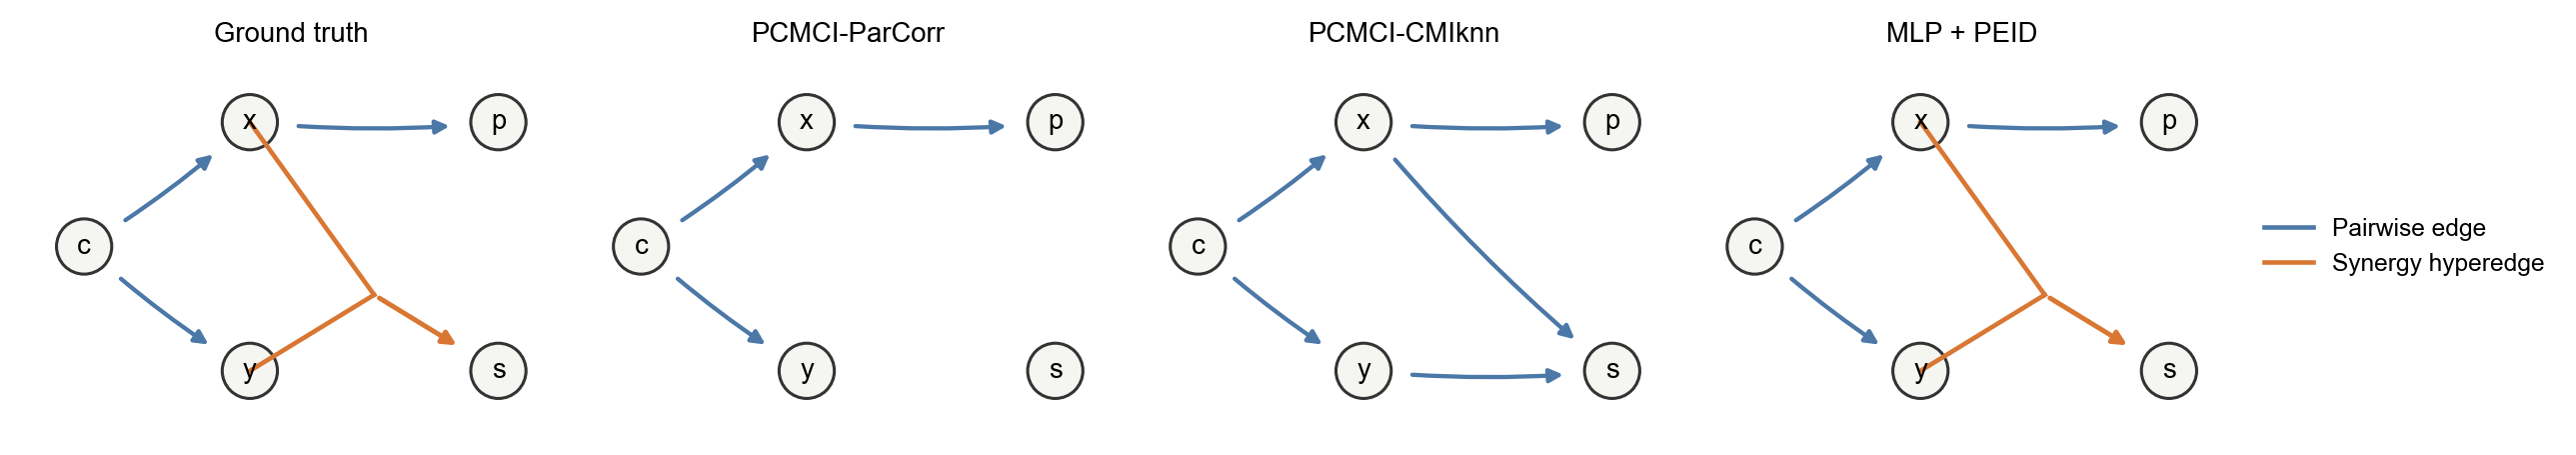

### Decomposition

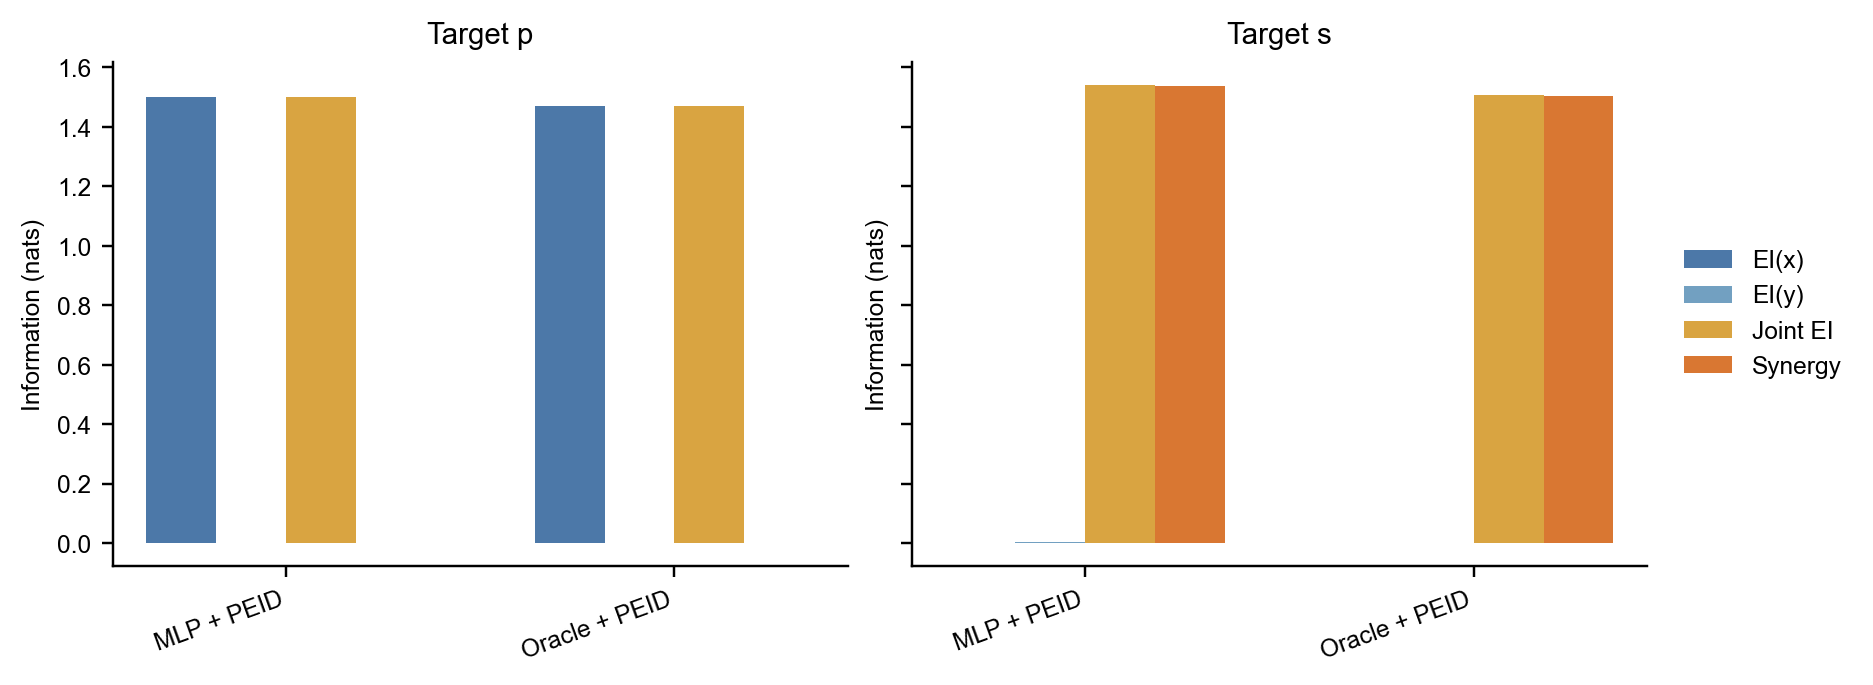

### Recovery Metrics

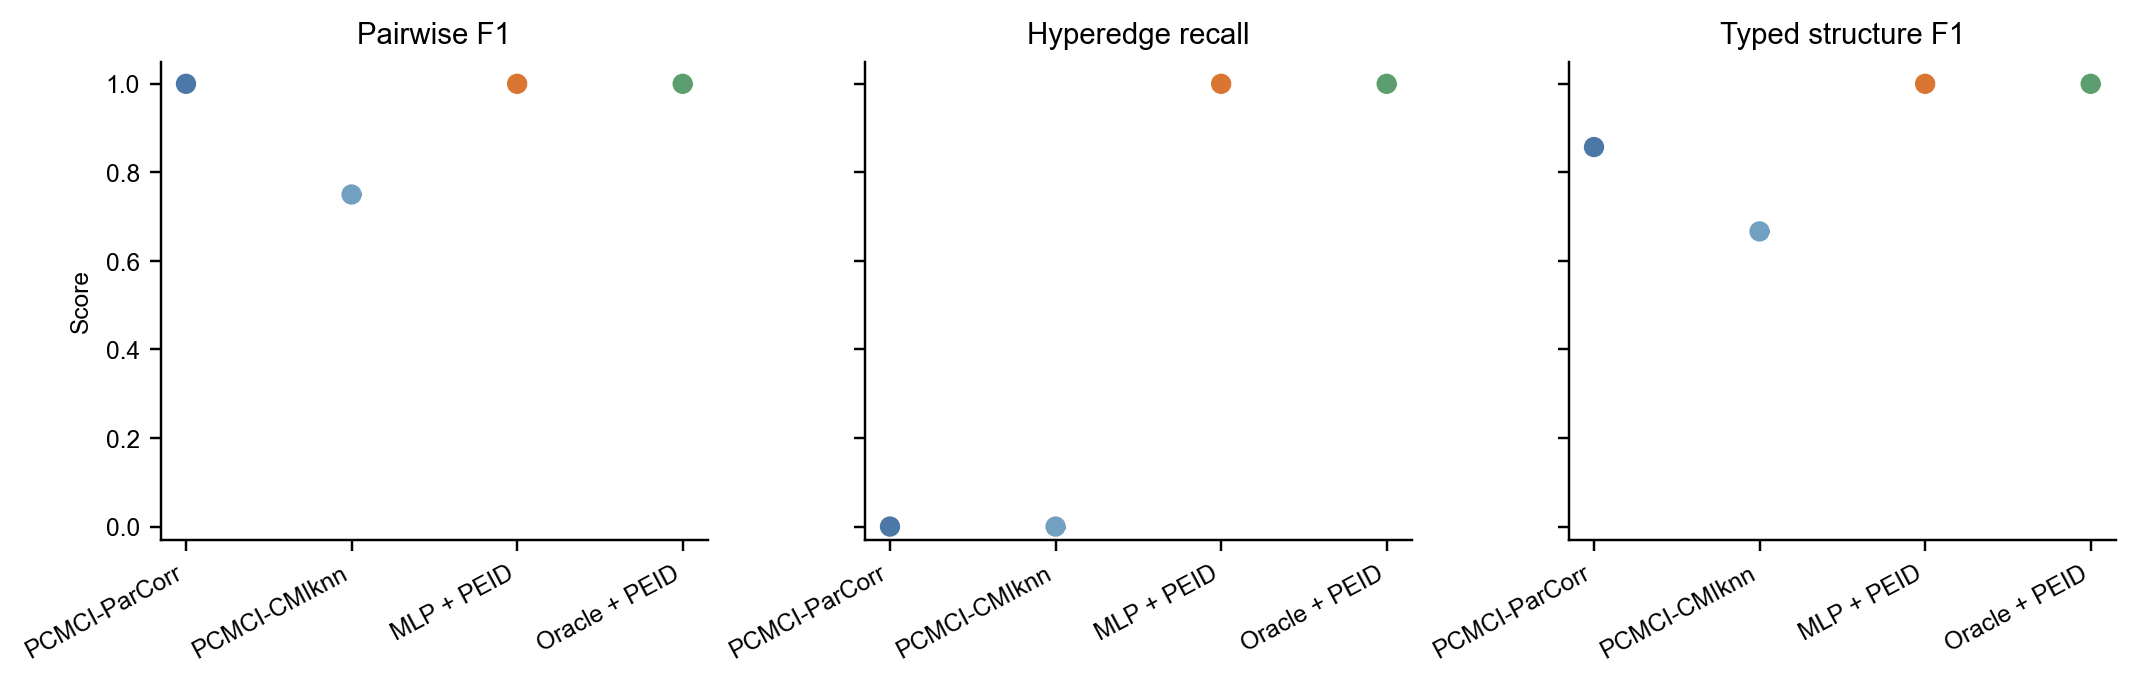

### Robustness

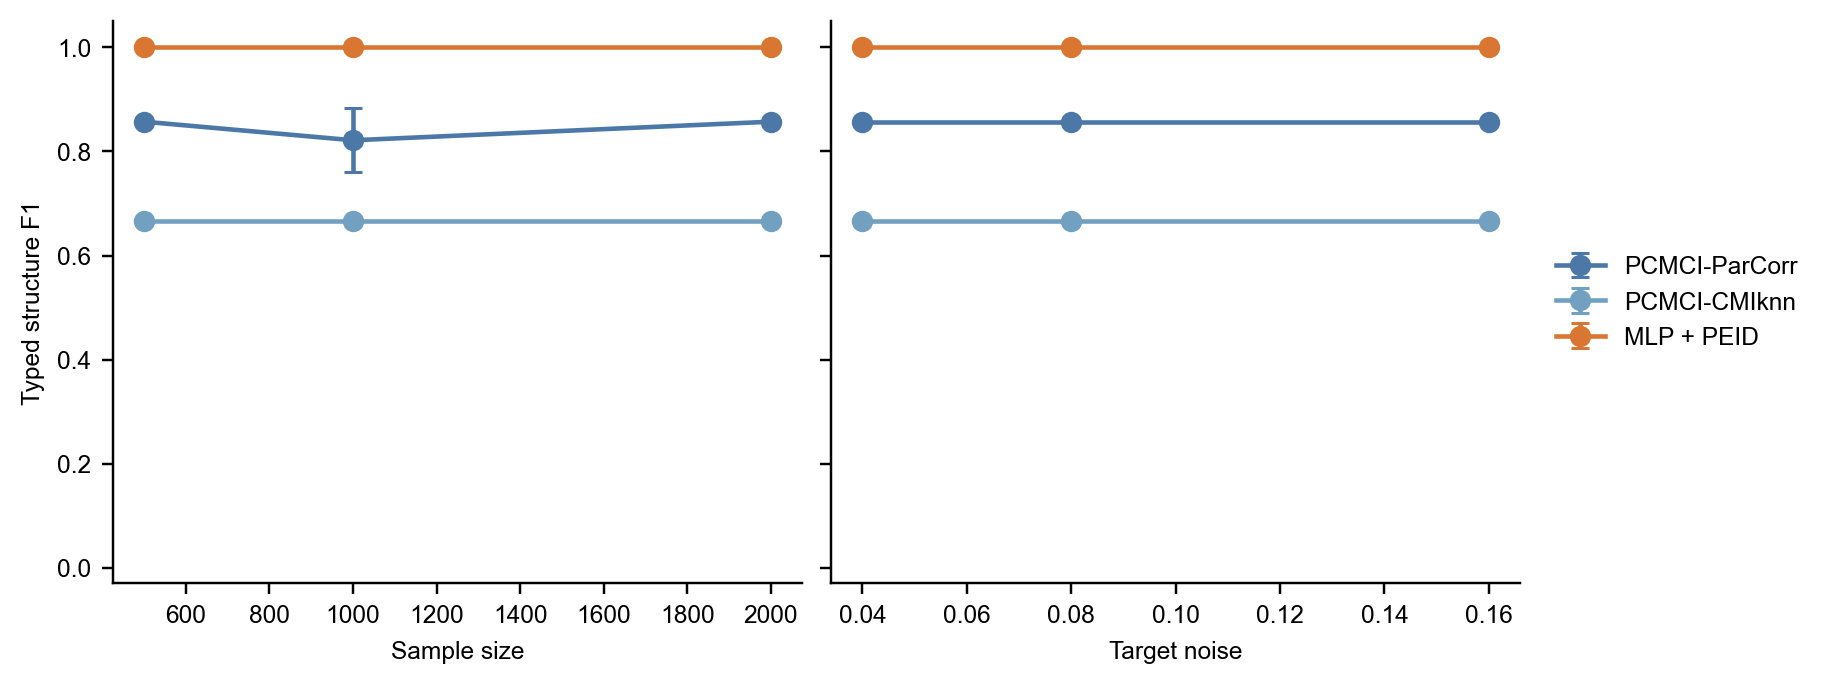

In [3]:
for name in ["graph_comparison", "decomposition", "recovery_metrics", "robustness"]:
    display(Markdown(f"### {name.replace('_', ' ').title()}"))
    display(Image(filename=output["figure_paths"][name]))


## 数值摘要与接受标准

重点检查三类证据：PCMCI 是否仍能恢复普通边；MLP+PEID 是否恢复 `{x,y}→s`；协同目标 `s` 的 synergy 是否远高于普通目标 `p`。完整模式还检验 MLP+PEID 相对 PCMCI-CMIknn 的 paired bootstrap typed-F1 优势。


In [4]:
primary_metrics = pd.DataFrame(summary["primary_metrics"])
display(primary_metrics[["seed", "method", "pairwise_f1", "hyperedge_recall", "typed_f1"]])

decomposition = pd.DataFrame(summary["primary_decomposition"])
display(decomposition[["seed", "method", "target", "x_ei", "y_ei", "joint_ei", "synergy"]])

display(pd.Series(summary["acceptance"], name="value").to_frame())


,seed,method,pairwise_f1,hyperedge_recall,typed_f1
0,0,PCMCI-ParCorr,1.00,0.0,0.857143
1,0,PCMCI-CMIknn,0.75,0.0,0.666667
2,0,MLP + PEID,1.00,1.0,1.000000
3,0,Oracle + PEID,1.00,1.0,1.000000
4,1,PCMCI-ParCorr,1.00,0.0,0.857143
5,1,PCMCI-CMIknn,0.75,0.0,0.666667
6,1,MLP + PEID,1.00,1.0,1.000000
7,1,Oracle + PEID,1.00,1.0,1.000000
8,2,PCMCI-ParCorr,1.00,0.0,0.857143
9,2,PCMCI-CMIknn,0.75,0.0,0.666667


,seed,method,target,x_ei,y_ei,joint_ei,synergy
0,0,MLP + PEID,p,1.496752,0.000035,1.497331,0.000545
1,0,MLP + PEID,s,0.004030,0.000829,1.642221,1.637362
2,0,Oracle + PEID,p,1.479304,0.000025,1.479200,-0.000129
3,0,Oracle + PEID,s,0.000784,0.000069,1.516280,1.515427
4,1,MLP + PEID,p,1.507216,0.000207,1.507426,0.000002
5,1,MLP + PEID,s,0.003241,0.003843,1.534594,1.527511
6,1,Oracle + PEID,p,1.454820,0.000152,1.454718,-0.000255
7,1,Oracle + PEID,s,0.001130,0.000711,1.525502,1.523662
8,2,MLP + PEID,p,1.514485,0.000133,1.516296,0.001678
9,2,MLP + PEID,s,0.000524,0.002269,1.492747,1.489954


,value
mlp_true_hyperedge_detected_count,5
mlp_primary_seed_count,5
mlp_detected_at_least_4_of_5,True
mean_synergy_ratio_s_over_p,138160.740696
synergy_ratio_exceeds_10,True
pcmci_parcorr_mean_pairwise_recall,1.0
typed_f1_mlp_minus_cmiknn_mean,0.333333
typed_f1_mlp_minus_cmiknn_bootstrap_ci95,"[0.3333333333333335, 0.3333333333333335]"
typed_f1_advantage_ci_above_zero,True


## 解释与限制

合理的预期是：PCMCI-ParCorr 恢复 `c→x`、`c→y`、`x→p`，但遗漏纯协同目标；PCMCI-CMIknn 能发现 `x`、`y` 与 `s` 的非线性条件依赖，却只能把 `{x,y}→s` 投影成两条 pairwise 边。MLP+PEID 则可在同一图中保留普通边，并把不可约联合影响表示为超边。因此这里的优势是**因果关系类型更完整、更符合生成机制**，不是简单声称 PCMCI 的 pairwise 依赖边毫无意义。

PEID 图解释的是固定真实动力学或固定 MLP 上的最大熵干预结构，不能自动解决隐藏混杂，也依赖干预支持、动力学模型质量和连续信息估计器。若完整模式的接受标准未满足，应保留失败结果并检查 MLP 拟合、干预范围与估计方差，而不筛选不利随机种子。
